# Data Standardisation & Cleaning Pipeline

Standardisation ensures consistency in format, units, and naming conventions across a dataset. It is the final step before data is reliable enough for analysis.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
print("Shape:", df.shape)

Shape: (891, 15)


## String Standardisation

Inconsistent string values are one of the most common data quality issues — the same value can appear in multiple forms (`'Male'`, `'male'`, `'MALE'`).

In [2]:
# Simulate messy categorical data
messy = pd.DataFrame({
    'sex':      ['Male', 'female', 'FEMALE', 'male', 'Male', ' female '],
    'embarked': ['S', 'southampton', 'C ', ' cherbourg', 'Q', 'Queenstown'],
    'class':    ['First', '1st', 'first class', '2nd', 'Second', 'THIRD']
})

print("Before standardisation:")
print(messy)

Before standardisation:
        sex     embarked        class
0      Male            S        First
1    female  southampton          1st
2    FEMALE           C   first class
3      male    cherbourg          2nd
4      Male            Q       Second
5   female    Queenstown        THIRD


In [3]:
clean = messy.copy()

# Lowercase + strip whitespace
clean['sex'] = clean['sex'].str.lower().str.strip()

# Extract first letter to normalise port names
clean['embarked'] = clean['embarked'].str.strip().str.upper().str[0]

# Map class aliases to a canonical form
class_map = {
    'first': 1, '1st': 1, 'first class': 1,
    '2nd': 2, 'second': 2,
    'third': 3, 'THIRD': 3
}
clean['class'] = clean['class'].str.lower().str.strip().map(class_map)

print("After standardisation:")
print(clean)

After standardisation:
      sex embarked  class
0    male        S      1
1  female        S      1
2  female        C      1
3    male        C      2
4    male        Q      2
5  female        Q      3


## Date/Time Standardisation

Date fields often arrive in multiple formats and must be unified before temporal analysis.

In [4]:
dates = pd.DataFrame({'raw_date': [
    '2024-01-15', '15/01/2024', 'January 15, 2024', '01-15-2024', '20240115'
]})

dates['parsed_date'] = pd.to_datetime(dates['raw_date'], infer_datetime_format=True, errors='coerce')

print(dates)

           raw_date parsed_date
0        2024-01-15  2024-01-15
1        15/01/2024         NaT
2  January 15, 2024         NaT
3        01-15-2024         NaT
4          20240115         NaT


## Unit Standardisation

Mixed units (miles vs km, USD vs GBP) create silent errors that are hard to detect without domain knowledge.

In [5]:
measurements = pd.DataFrame({
    'distance_km': [10.0, np.nan, 15.0, np.nan, 20.0],
    'distance_mi': [np.nan, 6.2, np.nan, 9.3, np.nan]
})

# Merge into a single 'distance_km' column
measurements['distance_unified_km'] = measurements['distance_km'].fillna(
    measurements['distance_mi'] * 1.60934
)

print(measurements)

   distance_km  distance_mi  distance_unified_km
0         10.0          NaN            10.000000
1          NaN          6.2             9.977908
2         15.0          NaN            15.000000
3          NaN          9.3            14.966862
4         20.0          NaN            20.000000


## Handling Structural Errors

In [6]:
# Impossible values — age cannot be negative or > 120
df_check = df[['age']].copy()
df_check.loc[5, 'age'] = -5    # inject bad value
df_check.loc[10, 'age'] = 200  # inject impossible value

print("Impossible ages detected:")
print(df_check[(df_check['age'] < 0) | (df_check['age'] > 120)])

# Replace with NaN, then impute
df_check.loc[(df_check['age'] < 0) | (df_check['age'] > 120), 'age'] = np.nan
df_check['age'] = df_check['age'].fillna(df_check['age'].median())
print("\nFixed (values replaced with median).")

Impossible ages detected:
      age
5    -5.0
10  200.0

Fixed (values replaced with median).


## Complete Cleaning Pipeline

Assembling all cleaning steps into a reusable function:

In [7]:
def clean_titanic(df_raw):
    df_c = df_raw.copy()

    # 1. Remove duplicates
    df_c = df_c.drop_duplicates()

    # 2. Drop columns with excessive missing data (> 40%)
    thresh = 0.40
    missing_pct = df_c.isnull().mean()
    cols_to_drop = missing_pct[missing_pct > thresh].index.tolist()
    df_c = df_c.drop(columns=cols_to_drop)
    if cols_to_drop:
        print(f"Dropped (>40% missing): {cols_to_drop}")

    # 3. Impute missing values
    df_c['age'] = df_c['age'].fillna(df_c['age'].median())
    for col in df_c.select_dtypes(include=['object', 'category']).columns:
        df_c[col] = df_c[col].fillna(df_c[col].mode()[0])

    # 4. Cap fare at 99th percentile
    fare_cap = df_c['fare'].quantile(0.99)
    df_c['fare'] = df_c['fare'].clip(upper=fare_cap)

    return df_c

df_cleaned = clean_titanic(df)

print(f"\nShape: {df.shape} → {df_cleaned.shape}")
print(f"Missing values remaining: {df_cleaned.isnull().sum().sum()}")

Dropped (>40% missing): ['deck']

Shape: (891, 15) → (784, 14)
Missing values remaining: 0


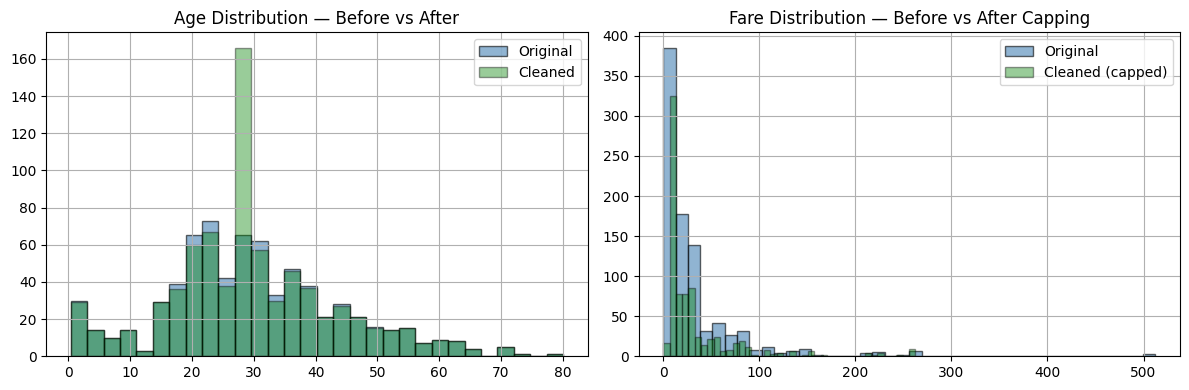

In [8]:
# Verify distributions are preserved after cleaning
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['age'].dropna().hist(bins=30, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.6, label='Original')
df_cleaned['age'].hist(bins=30, ax=axes[0], color='green', edgecolor='black', alpha=0.4, label='Cleaned')
axes[0].set_title('Age Distribution — Before vs After')
axes[0].legend()

df['fare'].hist(bins=40, ax=axes[1], color='steelblue', edgecolor='black', alpha=0.6, label='Original')
df_cleaned['fare'].hist(bins=40, ax=axes[1], color='green', edgecolor='black', alpha=0.4, label='Cleaned (capped)')
axes[1].set_title('Fare Distribution — Before vs After Capping')
axes[1].legend()

plt.tight_layout()
plt.show()

## Key Takeaways

| Problem | Detection | Fix |
|---|---|---|
| Inconsistent strings | `value_counts()` | `str.lower().str.strip()` |
| Mixed date formats | `pd.to_datetime(errors='coerce')` | Parse + unify |
| Mixed units | Domain knowledge | Convert to single unit |
| Impossible values | Range checks | Set to NaN, then impute |

Always run a **before/after comparison** of key distributions to verify cleaning didn't introduce bias.